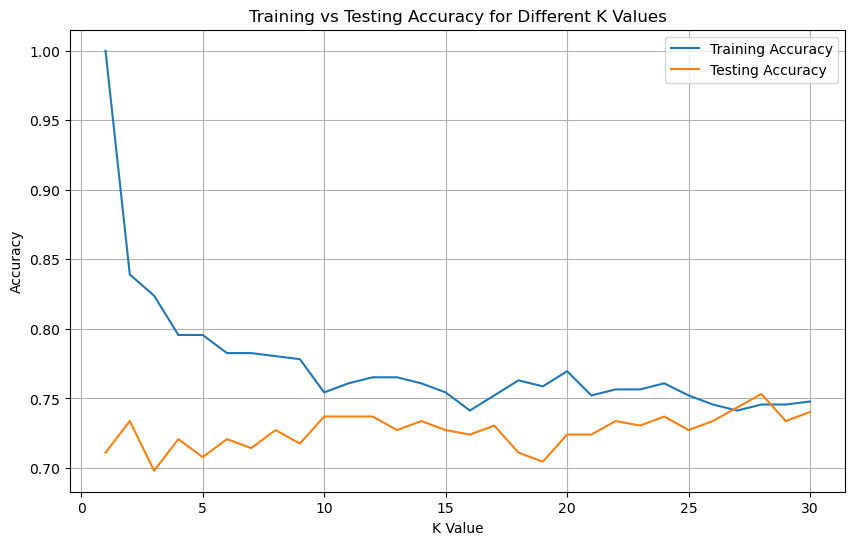

测试集准确率最高时的K值：28，对应的准确率：0.7532


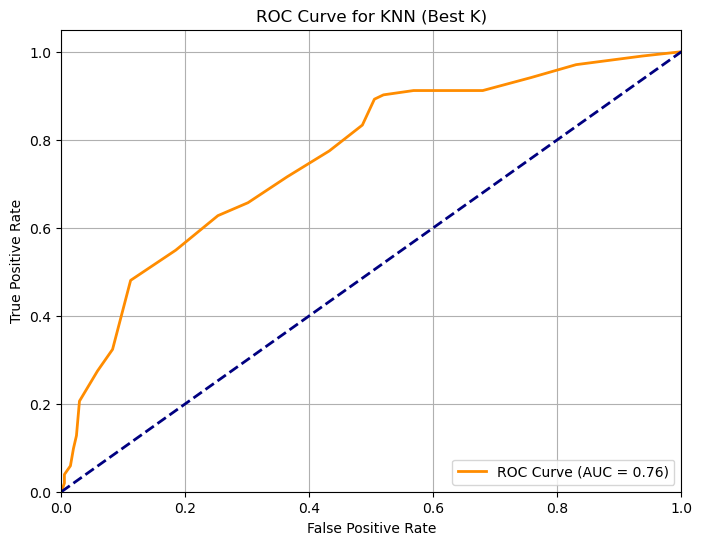

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_curve, auc

# 加载数据集
df = pd.read_csv('D:/notebook文件/实验1/diabetes.csv')  # 确保文件在当前目录，或替换为实际路径
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 划分训练集（60%）和测试集（40%）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)

# （1）选取不同K值，计算并绘制训练集与测试集精准率
k_values = range(1, 31)  # 测试K=1到30
train_accuracies = []
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    # 训练集准确率
    y_train_pred = knn.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)
    train_accuracies.append(train_acc)
    
    # 测试集准确率
    y_test_pred = knn.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_accuracies.append(test_acc)

# 绘制精准率图
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, label='Training Accuracy')
plt.plot(k_values, test_accuracies, label='Testing Accuracy')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy for Different K Values')
plt.legend()
plt.grid(True)
plt.show()

# （2）找到测试集准确率最高时的K值
max_test_acc = max(test_accuracies)
best_k = k_values[test_accuracies.index(max_test_acc)]
print(f"测试集准确率最高时的K值：{best_k}，对应的准确率：{max_test_acc:.4f}")

# （3）绘制准确率最高时的ROC曲线
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_test_proba = knn_best.predict_proba(X_test)[:, 1]  # 正类（患糖尿病）的概率

# 计算ROC曲线和AUC
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

# 绘制ROC曲线
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for KNN (Best K)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()